
# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Energy Usage Prediction**

---

| | |
|---|---|
| **Full name** | Wahid Ahmed |
| **Student ID** | 26010152 |
| **Email** | AhmedW7@cardiff.ac.uk |
| **Role** | `building_metadata.csv` Audit & Model Training |

## Notebook Summary

1. Building Metadata EDA
2. Building Metadata Preprocessing
3. Training Linear Regression, XGBoost, and CatBoost models
4. Feature Documentation Table

**Notes on this notebook.** The building-metadata audit, the feature-engineering imputation cascade, and the Linear Regression / XGBoost / CatBoost / dropped-MLP modelling pipeline were authored by Wahid. During team integration, Zahra added memory-aware sampling for the multi-GB final training file, the train/validation leakage check, and per-meter RMSLE evaluation (commit `a2ec923`), and synchronised the feature documentation table with the report version (commit `41a882e`).

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [33]:
#building = pd.read_csv('building_metadata.csv')
building = pd.read_csv(r"..\data\ashrae-energy-prediction\building_metadata.csv")


## 1. Building Metadata EDA

In [34]:
#Shape, Data types and number of non null values of attributes, first 10 and last 5 records

pd.set_option('display.max_columns', None, 'max_colwidth', None, 'display.expand_frame_repr', False) # print all columns in full, prevent line break

print('\n--- The number of data points (rows) and features (columns)---\n', building.shape)

print('\n---Information of the Building dataset --- \n')
print(building.info())
print('\n ---Column names of the dataset --- \n', building.columns)

#printing number of null values of each attribute
missing_values = building.isnull().sum()
print('Number of null values: \n',missing_values)

print('\nBelow is the first 10 lines of the dataset......\n', building.head(10))
print('\n\nBelow is the last 5 lines of the dataset......\n', building.tail(5))



--- The number of data points (rows) and features (columns)---
 (1449, 6)

---Information of the Building dataset --- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_id      1449 non-null   int64  
 1   building_id  1449 non-null   int64  
 2   primary_use  1449 non-null   object 
 3   square_feet  1449 non-null   int64  
 4   year_built   675 non-null    float64
 5   floor_count  355 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 68.1+ KB
None

 ---Column names of the dataset --- 
 Index(['site_id', 'building_id', 'primary_use', 'square_feet', 'year_built',
       'floor_count'],
      dtype='object')
Number of null values: 
 site_id           0
building_id       0
primary_use       0
square_feet       0
year_built      774
floor_count    1094
dtype: int64

Below is the first 10 lines of the dataset......


Attribute details from Kaggle:
* **site_id** - Foreign key for the weather files,
* **building_id** - Foreign key for training.csv,
* **primary_use** - Indicator of the primary category of activities for the building based on EnergyStar property type definitions,
* **square_feet** - Gross floor area of the building,
* **year_built** - Year building was opened,
* **floor_count** - Number of floors of the building.

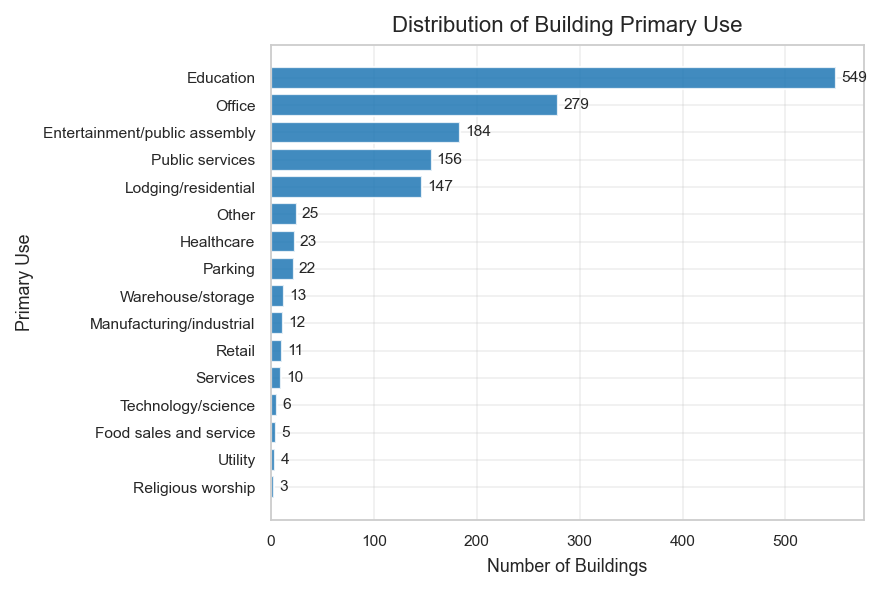

Saved to ..\docs\Report\Final Report\assets\primay_use.png


In [35]:
from pathlib import Path

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Plot distribution of primary_use (16 building types)
counts = building['primary_use'].value_counts()
fig, ax = plt.subplots(figsize=(5.6, 3.8), dpi=160)

ax.barh(counts.index, counts.values, color="#1f77b4", alpha=0.85)
ax.invert_yaxis()

ax.set_title("Distribution of Building Primary Use", fontsize=10)
ax.set_xlabel("Number of Buildings", fontsize=8)
ax.set_ylabel("Primary Use", fontsize=8)
ax.tick_params(axis='both', labelsize=7)

# Add counts on bars.
for y, value in enumerate(counts.values):
    ax.text(value + 5, y, int(value), va='center', fontsize=7)

fig.tight_layout()
fig.savefig(FINAL_REPORT_ASSETS_DIR / "primay_use.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {FINAL_REPORT_ASSETS_DIR / 'primay_use.png'}")


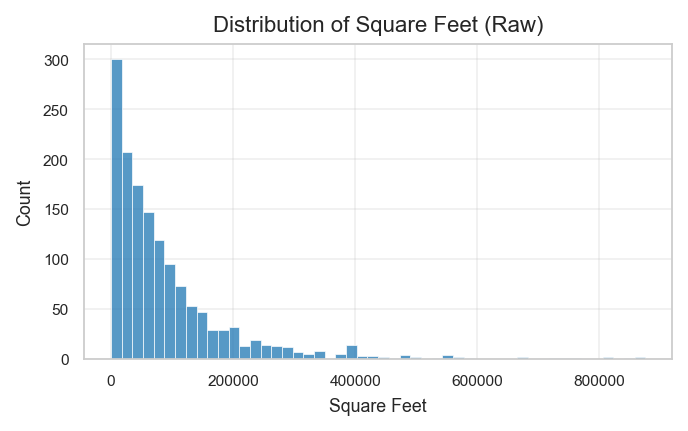

Saved to ..\docs\Report\Final Report\assets\raw_SF.png


In [36]:
from pathlib import Path

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Raw distribution of square feet
fig, ax = plt.subplots(figsize=(4.4, 2.8), dpi=160)

square_feet = building['square_feet'].replace([np.inf, -np.inf], np.nan).dropna()
ax.hist(square_feet, bins=50, color="#1f77b4", alpha=0.75, edgecolor="white", linewidth=0.4)

ax.set_title("Distribution of Square Feet (Raw)", fontsize=10)
ax.set_xlabel("Square Feet", fontsize=8)
ax.set_ylabel("Count", fontsize=8)
ax.tick_params(axis='both', labelsize=7)

fig.tight_layout()
fig.savefig(FINAL_REPORT_ASSETS_DIR / "raw_SF.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {FINAL_REPORT_ASSETS_DIR / 'raw_SF.png'}")


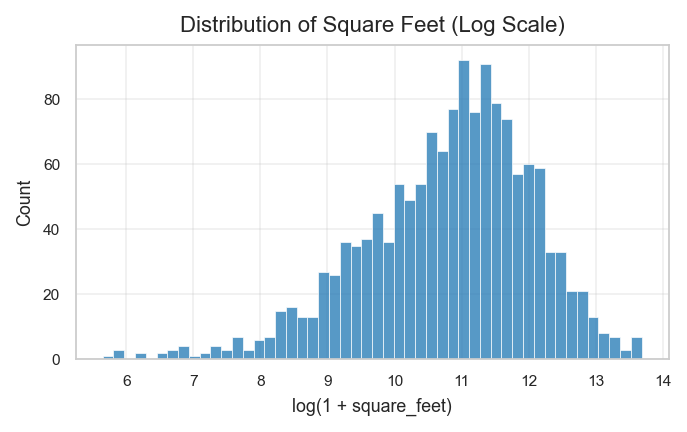

Saved to ..\docs\Report\Final Report\assets\engi_SF.png


In [37]:
from pathlib import Path

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Log distribution of square feet
fig, ax = plt.subplots(figsize=(4.4, 2.8), dpi=160)

log_square_feet = np.log1p(building['square_feet'].replace([np.inf, -np.inf], np.nan).dropna())
ax.hist(log_square_feet, bins=50, color="#1f77b4", alpha=0.75, edgecolor="white", linewidth=0.4)

ax.set_title("Distribution of Square Feet (Log Scale)", fontsize=10)
ax.set_xlabel("log(1 + square_feet)", fontsize=8)
ax.set_ylabel("Count", fontsize=8)
ax.tick_params(axis='both', labelsize=7)

fig.tight_layout()
fig.savefig(FINAL_REPORT_ASSETS_DIR / "engi_SF.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {FINAL_REPORT_ASSETS_DIR / 'engi_SF.png'}")


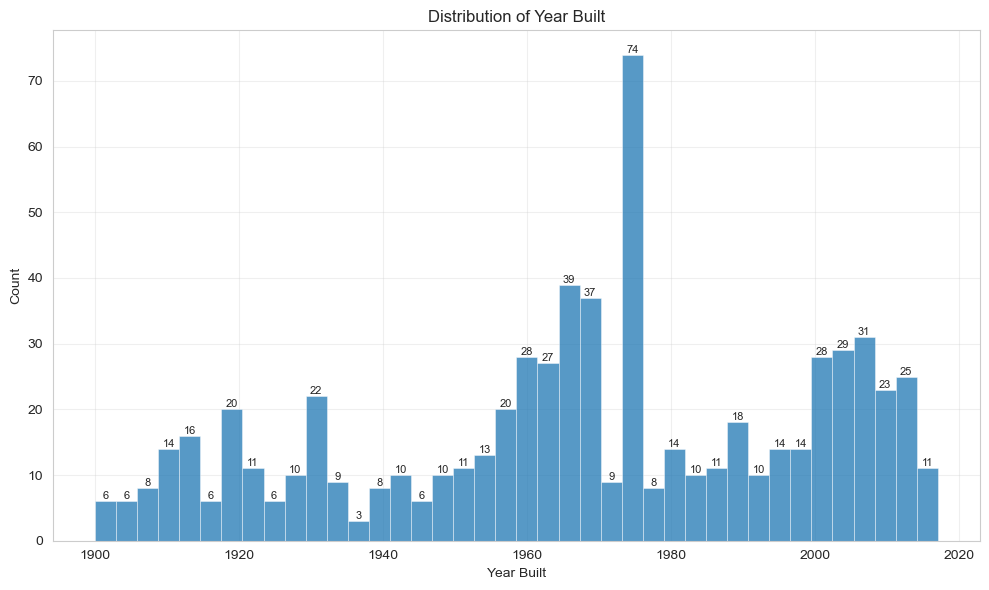

In [38]:
# Plot distribution of year_built (non-missing only)
year_built = building['year_built'].replace([np.inf, -np.inf], np.nan).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
counts, bins, patches = ax.hist(year_built, bins=40, color="#1f77b4", alpha=0.75, edgecolor="white", linewidth=0.4)

ax.set_title("Distribution of Year Built")
ax.set_xlabel("Year Built")
ax.set_ylabel("Count")

# Add counts.
for count, patch in zip(counts, patches):
    if count > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom',
            fontsize=8,
        )

plt.tight_layout()
plt.show()


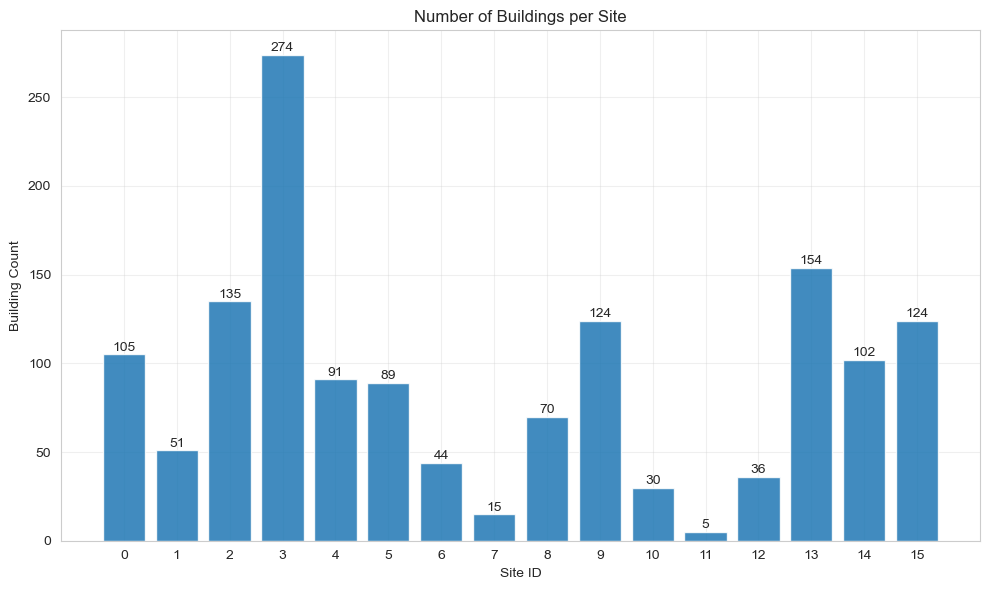

In [39]:
site_counts = building['site_id'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(site_counts.index.astype(str), site_counts.values, color="#1f77b4", alpha=0.85)

ax.set_title("Number of Buildings per Site")
ax.set_xlabel("Site ID")
ax.set_ylabel("Building Count")

# Add counts.
for x, value in enumerate(site_counts.values):
    ax.text(x, value + 2, int(value), ha='center')

plt.tight_layout()
plt.show()


**Key Findings**:
* Education has the highest number of buildings (38%)
* Religious worship, utility, food sales and service, and technology/science each have less than 10 buildings, so it might be better to delete those records
* log(1 + square_feet) scaling works good, values are within 14
* Many buildings were constructed between the 1960s and the 1980s.
* Site 11 only has 5 buildings

## 2. Building Metadata Preprocessing

In [40]:
#creating a flag attribute for missing values, 1 if missing, 0 if not
building['missing_floor_count_flag'] = building['floor_count'].isnull().astype(int)
building.head(5)

,site_id,building_id,primary_use,square_feet,year_built,floor_count,missing_floor_count_flag
0,0,0,Education,7432,2008.0,NaN,1
1,0,1,Education,2720,2004.0,NaN,1
2,0,2,Education,5376,1991.0,NaN,1
3,0,3,Education,23685,2002.0,NaN,1
4,0,4,Education,116607,1975.0,NaN,1


In [41]:
#dividing square feet into 5 categories (group by doesn't work with continuous values)
building['sqft_bin'] = pd.qcut(
    building['square_feet'],
    q=5,
    duplicates='drop'
)

#imputing floor count using primary_use, square_feet and site_id
building['floor_count'] = building['floor_count'].fillna(
    building.groupby(
        ['primary_use', 'site_id', 'sqft_bin'], observed=True
    )['floor_count'].transform('median')
)


#in case any of the previous group had all null values
building['floor_count'] = building['floor_count'].fillna(
    building.groupby(
        ['primary_use', 'sqft_bin'], observed=True
    )['floor_count'].transform('median')
)

#in case any of the previous group had all null values
building['floor_count'] = building['floor_count'].fillna(
    building.groupby('sqft_bin', observed=True)['floor_count']
            .transform('median')
)

#in case any of the previous group had all null values
building['floor_count'] = building['floor_count'].fillna(
    building['floor_count'].median()
)

building = building.drop(columns=['sqft_bin'])

#rounding floor counts
building['floor_count'] = building['floor_count'].round().astype(int)

building.head(10)

,site_id,building_id,primary_use,square_feet,year_built,floor_count,missing_floor_count_flag
0,0,0,Education,7432,2008.0,2,1
1,0,1,Education,2720,2004.0,2,1
2,0,2,Education,5376,1991.0,2,1
3,0,3,Education,23685,2002.0,2,1
4,0,4,Education,116607,1975.0,4,1
5,0,5,Education,8000,2000.0,2,1
6,0,6,Lodging/residential,27926,1981.0,3,1
7,0,7,Education,121074,1989.0,4,1
8,0,8,Education,60809,2003.0,5,1
9,0,9,Office,27000,2010.0,3,1


In [11]:
# #Dropping floor count due to 75% missing values
# try:
#   building.drop(['floor_count'], axis=1, inplace = True)
# except KeyError:
#   print('Attributes already removed')

# #checking if it's deleted or not
# print(building.head(10))

In [12]:
# Imputing year_built using primary_use + site_id
building['year_built'] = building['year_built'].fillna(
    building.groupby(['primary_use', 'site_id'],observed=True)['year_built'].transform('median')
)

# In case any of the previous groups had all null values, using only primary_use for median
building['year_built'] = building['year_built'].fillna(
    building.groupby('primary_use', observed=True)['year_built']
            .transform('median')
)

# In case primary_use had any null values, using the overall median
building['year_built'] = building['year_built'].fillna(
    building['year_built'].median()
)


In [13]:
# One-hot encode primary_use
building = pd.get_dummies(
    building,
    columns=['primary_use'],
    prefix='use',
    drop_first=False   # keep all categories (tree models handle fine)
)
print(building.head(10))

   site_id  building_id  square_feet  year_built  floor_count  missing_floor_count_flag  use_Education  use_Entertainment/public assembly  use_Food sales and service  use_Healthcare  use_Lodging/residential  use_Manufacturing/industrial  use_Office  use_Other  use_Parking  use_Public services  use_Religious worship  use_Retail  use_Services  use_Technology/science  use_Utility  use_Warehouse/storage
0        0            0         7432      2008.0            2                         1           True                              False                       False           False                    False                         False       False      False        False                False                  False       False         False                   False        False                  False
1        0            1         2720      2004.0            2                         1           True                              False                       False           False             

In [14]:
# convert ALL boolean columns to int
bool_cols = building.select_dtypes(include='bool').columns

building[bool_cols] = building[bool_cols].astype(int)

print(building.head(10))

   site_id  building_id  square_feet  year_built  floor_count  missing_floor_count_flag  use_Education  use_Entertainment/public assembly  use_Food sales and service  use_Healthcare  use_Lodging/residential  use_Manufacturing/industrial  use_Office  use_Other  use_Parking  use_Public services  use_Religious worship  use_Retail  use_Services  use_Technology/science  use_Utility  use_Warehouse/storage
0        0            0         7432      2008.0            2                         1              1                                  0                           0               0                        0                             0           0          0            0                    0                      0           0             0                       0            0                      0
1        0            1         2720      2004.0            2                         1              1                                  0                           0               0             

In [15]:
#Scaling square_feet feature using log1p
building['log_square_feet'] = np.log1p(building['square_feet'])

In [16]:
#Scaling year_built by calculating the age of the buildings
REFERENCE_YEAR = 2016  # ASHRAE dataset year

building['building_age'] = REFERENCE_YEAR - building['year_built']
building.head(10)

,site_id,building_id,square_feet,year_built,floor_count,missing_floor_count_flag,use_Education,use_Entertainment/public assembly,use_Food sales and service,use_Healthcare,use_Lodging/residential,use_Manufacturing/industrial,use_Office,use_Other,use_Parking,use_Public services,use_Religious worship,use_Retail,use_Services,use_Technology/science,use_Utility,use_Warehouse/storage,log_square_feet,building_age
0,0,0,7432,2008.0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.913685,8.0
1,0,1,2720,2004.0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.908755,12.0
2,0,2,5376,1991.0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.589886,25.0
3,0,3,23685,2002.0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.072639,14.0
4,0,4,116607,1975.0,4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.666573,41.0
5,0,5,8000,2000.0,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.987322,16.0
6,0,6,27926,1981.0,3,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,10.237349,35.0
7,0,7,121074,1989.0,4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.704165,27.0
8,0,8,60809,2003.0,5,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.015510,13.0
9,0,9,27000,2010.0,3,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,10.203629,6.0


In [17]:
#Dropping year_built and square_feet since they are no longer necessary
building.drop(columns=['year_built'], inplace=True)
building.drop(columns=['square_feet'], inplace=True)

In [18]:
#Confirming zero null remains in the dataset
missing_values = building.isnull().sum()
print(missing_values)

site_id                              0
building_id                          0
floor_count                          0
missing_floor_count_flag             0
use_Education                        0
use_Entertainment/public assembly    0
use_Food sales and service           0
use_Healthcare                       0
use_Lodging/residential              0
use_Manufacturing/industrial         0
use_Office                           0
use_Other                            0
use_Parking                          0
use_Public services                  0
use_Religious worship                0
use_Retail                           0
use_Services                         0
use_Technology/science               0
use_Utility                          0
use_Warehouse/storage                0
log_square_feet                      0
building_age                         0
dtype: int64


In [19]:
# Save processed building metadata to the shared data_processed folder
import os
os.makedirs("../data_processed", exist_ok=True)
building.to_csv("../data_processed/building_metadata_processed.csv", index=False)
print(f"Saved {len(building)} rows to ../data_processed/building_metadata_processed.csv")
print(f"Columns ({len(building.columns)}): {list(building.columns)}")

## 3. Training Linear Regression, XGBoost, and CatBoost models

In [2]:
#Loading Processed Dataset
#make sure to run the first code cell that imports all the libraries first

# Sample while reading — avoids loading the full 3.4GB file into memory
# Skips every 28th row to get ~500K rows spread across the full dataset
train = pd.read_csv(r"..\data_processed\final_train_with_features.csv",
                    skiprows=lambda i: i > 0 and i % 28 != 0)
test = pd.read_csv(r"..\data_processed\final_test_with_features.csv")

#test  = pd.read_csv('final_test_with_features.csv')


# train = pd.read_csv('final_train_with_features.csv',
#                     skiprows=lambda i: i > 0 and i % 28 != 0)
# test  = pd.read_csv('final_test_with_features.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (506536, 49)
Test shape:  (2614072, 49)


In [3]:
#Checking for data leakage
# align columns first
common_cols = list(set(train.columns).intersection(set(test.columns)))

train_sub = train[common_cols].copy()
test_sub  = test[common_cols].copy()

# merge to find duplicates
merged = train_sub.merge(test_sub, how='inner')

#If output > 0 data leakage EXISTS
print("Number of overlapping rows:", len(merged))

Number of overlapping rows: 0


In [4]:
#Shape, Data types and number of non null values of attributes, first 10 and last 5 records

pd.set_option('display.max_columns', None, 'max_colwidth', None, 'display.expand_frame_repr', False) # print all columns in full, prevent line break

print('\n--- The number of data points (rows) and features (columns)---\n', train.shape)

print('\n---Information of the Training dataset --- \n')
print(train.info())
print('\n ---Column names of the dataset --- \n', train.columns)

#printing number of null values of each attribute
missing_values = train.isnull().sum()
print('Number of null values: \n',missing_values)

print('\nBelow is the first 10 lines of the dataset......\n', train.head(10))
print('\n\nBelow is the last 5 lines of the dataset......\n', train.tail(5))



--- The number of data points (rows) and features (columns)---
 (506536, 49)

---Information of the Training dataset --- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506536 entries, 0 to 506535
Data columns (total 49 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   building_id                        506536 non-null  int64  
 1   meter                              506536 non-null  int64  
 2   timestamp                          506536 non-null  object 
 3   meter_reading                      506536 non-null  float64
 4   site_id                            506536 non-null  int64  
 5   floor_count                        506536 non-null  int64  
 6   hour                               506536 non-null  int64  
 7   day_of_week                        506536 non-null  int64  
 8   month                              506536 non-null  int64  
 9   day_of_year                        506536 non

In [5]:
drop_cols = ['meter_reading', 'log_meter_reading', 'timestamp','building_id']

X_train = train.drop(columns=drop_cols)
y_train = train['log_meter_reading']

X_test = test.drop(columns=drop_cols)

# align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
#Training Linear Regression
from sklearn.linear_model import LinearRegression
import joblib, os

# handle NaNs (LR cannot handle them)
X_train_lr = X_train.fillna(X_train.median())
X_test_lr  = X_test.fillna(X_train.median())

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

# predict log
y_pred_log_lr = lr_model.predict(X_test_lr)

# convert back
y_pred_lr = np.expm1(y_pred_log_lr)

# avoid negatives
y_pred_lr = np.maximum(y_pred_lr, 0)

# save model
os.makedirs('../outputs', exist_ok=True)
joblib.dump(lr_model, '../outputs/lr_model.pkl')

print("Linear Regression prediction done")
print("Model saved to ../outputs/lr_model.pkl")

Linear Regression prediction done
Model saved to ../outputs/lr_model.pkl


In [ ]:
#Training XGBoost Model
import sys, subprocess, importlib, joblib, os

subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
importlib.invalidate_caches()

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)

y_pred_log_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.expm1(np.maximum(y_pred_log_xgb, 0))

os.makedirs("../outputs", exist_ok=True)
joblib.dump(xgb_model, "../outputs/xgb_model.pkl")
print("XGBoost done. Model saved to ../outputs/xgb_model.pkl")

XGBoost done. Model saved to ../outputs/xgb_model.pkl


> **MLP model dropped** — MLPRegressor achieved RMSLE = 2.3096 on the validation set,
> significantly worse than all other models. Supervisor advised dropping one or two weak
> models. MLP was removed to keep the comparison table focused on competitive approaches.
> Code is preserved locally by Wahid if needed.

In [ ]:
#Training CatBoost Model
import subprocess, sys, importlib, joblib, os

subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "-q"])
importlib.invalidate_caches()

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train, y_train)

y_pred_log_cat = cat_model.predict(X_test)
y_pred_cat = np.expm1(np.maximum(y_pred_log_cat, 0))

os.makedirs("../outputs", exist_ok=True)
joblib.dump(cat_model, "../outputs/catboost_model.pkl")
print("CatBoost done. Model saved to ../outputs/catboost_model.pkl")

0:	learn: 1.8631246	total: 237ms	remaining: 1m 58s
100:	learn: 0.6269547	total: 10.3s	remaining: 40.8s
200:	learn: 0.5998458	total: 20s	remaining: 29.7s
300:	learn: 0.5842603	total: 29.6s	remaining: 19.6s
400:	learn: 0.5728686	total: 39.8s	remaining: 9.81s
499:	learn: 0.5640322	total: 49.5s	remaining: 0us
CatBoost done. Model saved to ../outputs/catboost_model.pkl


In [ ]:
#Calculating RMSLE of all the Models

import pandas as pd
from sklearn.metrics import mean_squared_log_error
import joblib

y_true = test["meter_reading"]

rmsle_lr  = np.sqrt(mean_squared_log_error(y_true, y_pred_lr))
rmsle_xgb = np.sqrt(mean_squared_log_error(y_true, y_pred_xgb))
rmsle_cat = np.sqrt(mean_squared_log_error(y_true, y_pred_cat))

print("=== Overall RMSLE ===")
print(f"LR RMSLE:       {rmsle_lr:.4f}")
print(f"XGBoost RMSLE:  {rmsle_xgb:.4f}")
print(f"CatBoost RMSLE: {rmsle_cat:.4f}")

meter_names = {0: "Electricity", 1: "Chilled Water", 2: "Steam", 3: "Hot Water"}

results = test[["meter", "meter_reading"]].copy()
results["pred_lr"]  = y_pred_lr
results["pred_xgb"] = y_pred_xgb
results["pred_cat"] = y_pred_cat

for model_name, pred_col in [("LR", "pred_lr"), ("XGBoost", "pred_xgb"), ("CatBoost", "pred_cat")]:
    print(f"\n=== {model_name} RMSLE per Meter Type ===")
    for m, grp in results.groupby("meter"):
        r = np.sqrt(mean_squared_log_error(grp["meter_reading"], grp[pred_col]))
        print(f"  {meter_names.get(m, m)}: {r:.4f}")

# Save LR/XGBoost/CatBoost results using a model-based output name
linear_boosting_results = pd.DataFrame([
    {"Model": "Linear Regression", "Overall RMSLE": rmsle_lr},
    {"Model": "XGBoost",           "Overall RMSLE": rmsle_xgb},
    {"Model": "CatBoost",          "Overall RMSLE": rmsle_cat},
])
display(linear_boosting_results)
linear_boosting_results.to_csv("../outputs/linear_boosting_model_results.csv", index=False)
print("\nSaved to ../outputs/linear_boosting_model_results.csv")

=== Overall RMSLE ===
LR RMSLE:       1.5989
XGBoost RMSLE:  0.5210
CatBoost RMSLE: 0.5230

=== LR RMSLE per Meter Type ===
  Electricity: 0.9970
  Chilled Water: 2.1877
  Steam: 2.3859
  Hot Water: 2.1438

=== XGBoost RMSLE per Meter Type ===
  Electricity: 0.2612
  Chilled Water: 0.6896
  Steam: 0.7297
  Hot Water: 1.0927

=== CatBoost RMSLE per Meter Type ===
  Electricity: 0.2661
  Chilled Water: 0.6917
  Steam: 0.7294
  Hot Water: 1.0931


,Model,Overall RMSLE
0,Linear Regression,1.598901
1,XGBoost,0.520998
2,CatBoost,0.523007



Saved to ../outputs/linear_boosting_model_results.csv


---

## 4. Feature Documentation Table

Delivered feature documentation table matching `docs/CMT307 Feature Report.docx`.
This includes the model input fields plus the identifier/target fields documented for the report.


In [10]:
import pandas as pd

# Matches docs/CMT307 Feature Report.docx
feature_docs = pd.DataFrame([
    {'Feature Name': 'building_id', 'Description': 'Unique ID for each Building', 'Origin': 'building_metadata + train', 'Feature Engineered': 'No'},
    {'Feature Name': 'meter', 'Description': 'The meter id code. Read as {0: electricity, 1: chilledwater, 2: steam, 3: hotwater}. Not every building has all meter types.', 'Origin': 'train', 'Feature Engineered': 'No'},
    {'Feature Name': 'timestamp', 'Description': 'When the measurement was taken', 'Origin': 'train', 'Feature Engineered': 'No'},
    {'Feature Name': 'meter_reading', 'Description': 'The target variable. Energy consumption in kWh (or equivalent). Note that this is real data with measurement error, which we expect will impose a baseline level of modeling error. UPDATE: as discussed here, the site 0 electric meter readings are in kBTU.', 'Origin': 'train', 'Feature Engineered': 'No'},
    {'Feature Name': 'log_meter_reading', 'Description': 'Log-transformed target variable using log1p(meter_reading). Reduces skewness and stabilises variance for regression.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'lag_24h', 'Description': 'Meter reading 24 hours prior, grouped by building_id and meter. Captures daily periodicity in energy consumption.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'lag_72h', 'Description': 'Meter reading 72 hours (3 days) prior, grouped by building_id and meter. Captures medium-term consumption trends.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'lag_168h', 'Description': 'Meter reading 168 hours (1 week) prior, grouped by building_id and meter. Captures weekly seasonality in energy usage.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'rolling_mean_24h', 'Description': 'Rolling mean of meter reading over the past 24 hours, grouped by building_id and meter. Smooths short-term fluctuations.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'rolling_std_24h', 'Description': 'Rolling standard deviation of meter reading over the past 24 hours, grouped by building_id and meter. Captures short-term consumption volatility.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'rolling_mean_168h', 'Description': 'Rolling mean of meter reading over the past 168 hours (1 week), grouped by building_id and meter. Captures weekly average consumption level.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'hour', 'Description': 'Hour of the day extracted from timestamp (0-23). Captures intraday energy usage patterns.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'day_of_week', 'Description': 'Day of the week extracted from timestamp (0=Monday, 6=Sunday). Captures weekly occupancy patterns.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'month', 'Description': 'Month of the year extracted from timestamp (1-12). Captures seasonal energy demand variation.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'day_of_year', 'Description': 'Day of the year extracted from timestamp (1-366). Captures annual consumption cycle at a finer granularity than month.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'season', 'Description': 'Season derived from month (0=Winter, 1=Spring, 2=Summer, 3=Autumn). Provides a coarse seasonal signal for heating and cooling demand.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'is_weekend', 'Description': 'Binary flag: 1 if the day falls on a Saturday or Sunday, 0 otherwise. Captures reduced occupancy and energy use on weekends.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'is_business_hours', 'Description': 'Binary flag: 1 if the hour is within standard business hours (08:00-18:00 on weekdays), 0 otherwise. Captures occupancy-driven energy patterns.', 'Origin': 'train', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'site_id', 'Description': 'Unique id for each Site', 'Origin': 'building_metadata', 'Feature Engineered': 'No'},
    {'Feature Name': 'floor_count', 'Description': 'Number of floors of the building', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'missing_floor_count_flag', 'Description': 'Binary flag: 1 if floor_count was originally missing for that building, 0 if present. Preserves missingness as a signal for the model.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'building_age', 'Description': 'Age of the building calculated as 2016 minus year_built. Older buildings tend to be less energy-efficient.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'log_square_feet', 'Description': 'Log-transformed gross floor area using log1p(square_feet). Reduces right skew from a small number of very large buildings.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Public services', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Public services. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Religious worship', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Religious worship. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Parking', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Parking. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Other', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Other. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Office', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Office. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Manufacturing/industrial', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Manufacturing/industrial. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Lodging/residential', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Lodging/residential. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Healthcare', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Healthcare. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Food sales and service', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Food sales and service. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Entertainment/public assembly', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Entertainment/public assembly. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Education', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Education. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Retail', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Retail. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Services', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Services. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Technology/science', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Technology/science. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Utility', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Utility. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'use_Warehouse/storage', 'Description': 'Binary indicator (0/1): 1 if the building primary use is Warehouse/storage. One-hot encoded from primary_use.', 'Origin': 'building_metadata', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'air_temperature', 'Description': 'Outdoor air temperature in degrees Celsius at the site. Strong driver of heating and cooling energy demand.', 'Origin': 'weather', 'Feature Engineered': 'No'},
    {'Feature Name': 'cloud_coverage', 'Description': 'Fraction of the sky covered by clouds measured in oktas (0-9). Influences solar gain and lighting energy use.', 'Origin': 'weather', 'Feature Engineered': 'No'},
    {'Feature Name': 'dew_temperature', 'Description': 'Dew point temperature in degrees Celsius. Indicator of atmospheric humidity; influences cooling load.', 'Origin': 'weather', 'Feature Engineered': 'No'},
    {'Feature Name': 'precip_depth_1_hr', 'Description': 'Precipitation depth over the preceding 1 hour in mm. Can indicate extreme weather events affecting energy use.', 'Origin': 'weather', 'Feature Engineered': 'No'},
    {'Feature Name': 'wind_direction', 'Description': 'Wind direction in degrees (0-360). Affects building envelope heat loss through wind-driven infiltration.', 'Origin': 'weather', 'Feature Engineered': 'No'},
    {'Feature Name': 'wind_speed', 'Description': 'Wind speed in metres per second. Higher wind speeds increase building heat loss and ventilation load.', 'Origin': 'weather', 'Feature Engineered': 'No'},
    {'Feature Name': 'precip_was_missing', 'Description': 'Binary flag: 1 if precip_depth_1_hr was originally missing, 0 otherwise. Preserves missingness pattern as a potential signal.', 'Origin': 'weather', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'sea_level_pressure', 'Description': 'Atmospheric pressure at sea level in hPa. Proxy for weather system type affecting temperature and humidity.', 'Origin': 'weather', 'Feature Engineered': 'No'},
    {'Feature Name': 'relative_humidity', 'Description': 'Relative humidity (%) calculated from air temperature and dew temperature. Directly influences cooling and HVAC energy demand.', 'Origin': 'weather', 'Feature Engineered': 'Yes'},
    {'Feature Name': 'temp_diff_from_comfort', 'Description': 'Absolute difference between air temperature and a 21 degrees Celsius comfort baseline, calculated as abs(air_temperature - 21). Captures the magnitude of heating or cooling demand regardless of direction.', 'Origin': 'weather', 'Feature Engineered': 'Yes'},
])

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 60)
display(feature_docs.set_index("Feature Name"))

not_engineered_count = (feature_docs["Feature Engineered"] == "No").sum()
engineered_count = (feature_docs["Feature Engineered"] == "Yes").sum()
model_excluded_fields = {"building_id", "timestamp", "meter_reading", "log_meter_reading"}
model_input_count = (~feature_docs["Feature Name"].isin(model_excluded_fields)).sum()

print(f"\nTotal documented fields: {len(feature_docs)}")
print(f"  Not engineered     : {not_engineered_count}")
print(f"  Engineered         : {engineered_count}")
print(f"  Model input fields : {model_input_count}")
print(f"  By origin: {feature_docs.groupby('Origin')['Feature Name'].count().to_dict()}")


,Description,Origin,Feature Engineered
Feature Name,,,
building_id,Unique ID for each Building,building_metadata + train,No
meter,"The meter id code. Read as {0: electricity, 1: chilledwater, 2: steam, 3: ho...",train,No
timestamp,When the measurement was taken,train,No
meter_reading,The target variable. Energy consumption in kWh (or equivalent). Note that th...,train,No
log_meter_reading,Log-transformed target variable using log1p(meter_reading). Reduces skewness...,train,Yes
lag_24h,"Meter reading 24 hours prior, grouped by building_id and meter. Captures dai...",train,Yes
lag_72h,"Meter reading 72 hours (3 days) prior, grouped by building_id and meter. Cap...",train,Yes
lag_168h,"Meter reading 168 hours (1 week) prior, grouped by building_id and meter. Ca...",train,Yes
rolling_mean_24h,"Rolling mean of meter reading over the past 24 hours, grouped by building_id...",train,Yes



Total documented fields: 49
  Not engineered     : 12
  Engineered         : 37
  Model input fields : 45
  By origin: {'building_metadata': 21, 'building_metadata + train': 1, 'train': 17, 'weather': 10}
